# NPI Counterfactual Figures

This notebook generates:
- **Figure 5**: Effects of different intervention strategies (3 panels)
- **Figure S-NPI**: All 12 standard scenarios (2 panels)

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, yaml
from pathlib import Path
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'axes.labelsize': 10, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
})
for font in ['Arial', 'Helvetica', 'DejaVu Sans']:
    try:
        plt.rcParams['font.family'] = font
        break
    except:
        pass

PROJ_ROOT = Path('../..').resolve()
PAPER_DIR = PROJ_ROOT / 'paper' / 'final'
SIM_DIR = PROJ_ROOT / 'analysis' / 'simulations'
SCENARIO_DIR = PAPER_DIR / 'analysis' / 'simulations' / 'results' / 'baseline'
FIG_DIR = PAPER_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

with open(SIM_DIR / 'config.yaml') as f:
    config = yaml.safe_load(f)

def hpd(samples, credible_mass=0.95):
    sorted_samples = np.sort(samples)
    n = len(sorted_samples)
    interval_size = int(np.ceil(credible_mass * n))
    widths = sorted_samples[interval_size:] - sorted_samples[:n - interval_size]
    best = int(np.argmin(widths))
    return sorted_samples[best], sorted_samples[best + interval_size - 1]

def style_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def load_results(scenario):
    return pd.read_csv(SCENARIO_DIR / f'{scenario}_results.csv')

abc = pd.read_csv(SCENARIO_DIR / 'abc_accepted.csv')
MEDIAN_OFFSET = int(np.median(abc['tmrca_offset']))
TX_DETECTION = datetime(2024, 3, 25)
TMRCA_DATE = TX_DETECTION - timedelta(days=MEDIAN_OFFSET)
NPI_DATE = TX_DETECTION + timedelta(days=35)

print(f'PAPER_DIR: {PAPER_DIR}')
print(f'SCENARIO_DIR: {SCENARIO_DIR}')
print(f'FIG_DIR: {FIG_DIR}')
print(f'Median tMRCA offset: {MEDIAN_OFFSET} days')
print(f'tMRCA date: {TMRCA_DATE.strftime("%Y-%m-%d")}')
print(f'TX detection: {TX_DETECTION.strftime("%Y-%m-%d")}')
print(f'NPI date: {NPI_DATE.strftime("%Y-%m-%d")}')

PAPER_DIR: /Users/jpekar/Desktop/Projects/2026_b313_phylogeography/paper/final
SCENARIO_DIR: /Users/jpekar/Desktop/Projects/2026_b313_phylogeography/paper/final/analysis/simulations/results/baseline
FIG_DIR: /Users/jpekar/Desktop/Projects/2026_b313_phylogeography/paper/final/figures
Median tMRCA offset: 91 days
tMRCA date: 2023-12-25
TX detection: 2024-03-25
NPI date: 2024-04-29


## Define scenarios and colors

In [2]:
# Figure 5 scenarios (6 key scenarios)
FIG5_SCENARIOS = [
    ('no_npi',                 'No intervention',                                '#e6ab02', '-'),
    ('npi_day35',              'Federal order date, posterior strength',          '#333333', '-'),
    ('strength_f010',          'Federal order date, 90% between-state',          '#7570b3', '-'),
    ('day0_f010',              'At detection, 90% between-state',                '#d95f02', '--'),
    ('tmrca_30d',              '30d post-tMRCA, 90% between-state',              '#d62728', '--'),
    ('within90_between90',     'Federal order date, 90% within + 90% between',   '#1b9e77', '-'),
]

# Checkpoint weeks from results columns
CHECKPOINT_WEEKS = [4, 8, 12, 16, 20, 24, 32, 40, 52, 64, 78, 92, 104]
CHECKPOINT_COLS = [f'counties_w{w}' for w in CHECKPOINT_WEEKS]

# S-NPI scenarios (12 — trimmed to informative set)
S_NPI_SCENARIOS = [
    ('no_npi', 'No intervention', 'Baseline'),
    ('npi_day35', 'Federal order date, posterior strength', 'Baseline'),
    ('strength_f090', 'Federal order date, 10% between-state', 'Between-state strength'),
    ('strength_f070', 'Federal order date, 30% between-state', 'Between-state strength'),
    ('strength_f050', 'Federal order date, 50% between-state', 'Between-state strength'),
    ('strength_f030', 'Federal order date, 70% between-state', 'Between-state strength'),
    ('strength_f010', 'Federal order date, 90% between-state', 'Between-state strength'),
    ('day16_f010', 'Day 16 post-detection, 90% between-state', 'Timing (90% standardized)'),
    ('day0_f010', 'At detection, 90% between-state', 'Timing (90% standardized)'),
    ('tmrca_60d', '60d post-tMRCA, 90% between-state', 'Pre-detection surveillance'),
    ('tmrca_30d', '30d post-tMRCA, 90% between-state', 'Pre-detection surveillance'),
    ('within90_between90', 'Federal order date, 90% within + 90% between', 'Within + between'),
]

CATEGORY_COLORS = {
    'Baseline': '#333333',
    'Between-state strength': '#3182bd',
    'Timing (90% standardized)': '#d62728',
    'Pre-detection surveillance': '#e7298a',
    'Within + between': '#2ca02c',
}

## Load all scenario data

In [3]:
# Collect all unique scenario names
all_scenario_names = set()
for s, _, _ in S_NPI_SCENARIOS:
    all_scenario_names.add(s)
for s, _, _, _ in FIG5_SCENARIOS:
    all_scenario_names.add(s)
# Also need day0_f010, day16_f010 for dose-response
all_scenario_names.update(['day0_f010', 'day16_f010', 'tmrca_60d'])

data = {}
for s in sorted(all_scenario_names):
    fp = SCENARIO_DIR / f'{s}_results.csv'
    if fp.exists():
        data[s] = pd.read_csv(fp)
        print(f'{s}: {len(data[s]):,} sims')
    else:
        print(f'WARNING: {s} not found')

day0_f010: 375,000 sims
day16_f010: 375,000 sims
no_npi: 375,000 sims
npi_day35: 375,000 sims
strength_f010: 375,000 sims
strength_f030: 375,000 sims
strength_f050: 375,000 sims
strength_f070: 375,000 sims
strength_f090: 375,000 sims
tmrca_30d: 375,000 sims
tmrca_60d: 375,000 sims
within90_between90: 375,000 sims


## Figure 5: Effects of Different Intervention Strategies

Three panels:
- **A**: Cumulative counties over time (6 scenarios)
- **B**: Final county distributions (dot-and-whisker)
- **C**: Timing dose-response (all at 90% effectiveness)

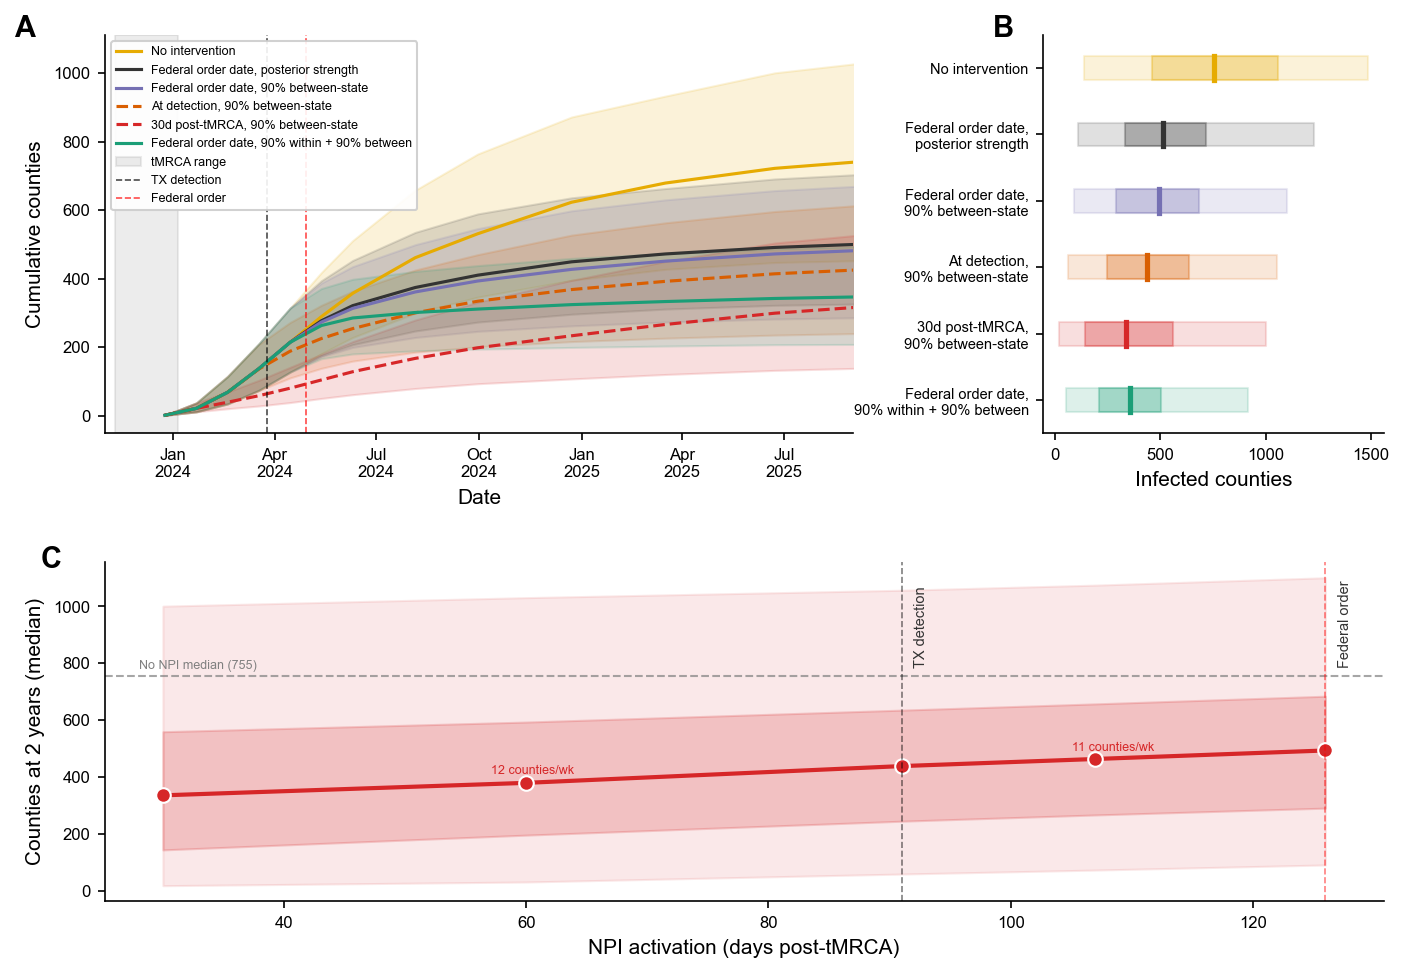

In [4]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(11, 7.5))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 0.85], width_ratios=[2.2, 1],
                      hspace=0.35, wspace=0.35)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, :])

# ── Panel A: Cumulative counties over time ──
ax = ax_a

# Use all checkpoint weeks, starting from week 0 (seed = 1 county)
WEEKS_PANEL_A = [0] + CHECKPOINT_WEEKS
COLS_PANEL_A = [None] + CHECKPOINT_COLS

DATE_START = datetime(2023, 11, 1)
DATE_END = datetime(2025, 9, 1)

for scenario, label, color, ls in FIG5_SCENARIOS:
    df = data[scenario]
    medians = []
    q25s = []
    q75s = []
    dates = []
    for w, col in zip(WEEKS_PANEL_A, COLS_PANEL_A):
        if col is None:
            medians.append(1)
            q25s.append(1)
            q75s.append(1)
        else:
            vals = df[col].values
            medians.append(np.median(vals))
            q25s.append(np.percentile(vals, 25))
            q75s.append(np.percentile(vals, 75))
        dates.append(TMRCA_DATE + timedelta(weeks=w))
    ax.plot(dates, medians, color=color, ls=ls, lw=1.5, label=label)
    ax.fill_between(dates, q25s, q75s, color=color, alpha=0.15)

# Vertical markers
abc_offsets = abc['tmrca_offset'].values
tmrca_min_date = TX_DETECTION - timedelta(days=int(abc_offsets.max()))
tmrca_max_date = TX_DETECTION - timedelta(days=int(abc_offsets.min()))
ax.axvspan(tmrca_min_date, tmrca_max_date, color='gray', alpha=0.15, zorder=0, label='tMRCA range')
ax.axvline(TX_DETECTION, color='black', ls='--', lw=0.8, alpha=0.7, label='TX detection')
ax.axvline(NPI_DATE, color='red', ls='--', lw=0.8, alpha=0.7, label='Federal order')

ax.set_xlim(DATE_START, DATE_END)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative counties')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.legend(fontsize=6, loc='upper left', framealpha=0.9)
style_ax(ax)
ax.text(-0.12, 1.05, 'A', transform=ax.transAxes, fontsize=14, fontweight='bold', va='top')

# ── Panel B: Final counties — bar-style (fill_between rectangles) ──
ax = ax_b

bar_height = 0.18

def break_label(label):
    label = label.replace(' (', '\n(')
    label = label.replace(', ', ',\n')
    return label

for i, (scenario, label, color, ls) in enumerate(FIG5_SCENARIOS):
    vals = data[scenario]['counties_w104'].values
    med = np.median(vals)
    q025, q25, q75, q975 = np.percentile(vals, [2.5, 25, 75, 97.5])
    y = i
    ax.fill_between([q025, q975], y - bar_height, y + bar_height,
                    color=color, alpha=0.15, zorder=1)
    ax.fill_between([q25, q75], y - bar_height, y + bar_height,
                    color=color, alpha=0.30, zorder=2)
    ax.plot([med, med], [y - bar_height, y + bar_height],
            color=color, lw=2.5, zorder=4)

ax.set_yticks(range(len(FIG5_SCENARIOS)))
ax.set_yticklabels([break_label(label) for _, label, _, _ in FIG5_SCENARIOS], fontsize=7)
ax.set_xlabel('Infected counties')
ax.set_ylim(len(FIG5_SCENARIOS) - 0.5, -0.5)
style_ax(ax)
ax.text(-0.15, 1.05, 'B', transform=ax.transAxes, fontsize=14, fontweight='bold', va='top')

# ── Panel C: Timing dose-response (all at 90% effectiveness) ──
ax = ax_c

dose_scenarios = [
    ('tmrca_30d',      30),
    ('tmrca_60d',      60),
    ('day0_f010',      MEDIAN_OFFSET),
    ('day16_f010',     MEDIAN_OFFSET + 16),
    ('strength_f010',  MEDIAN_OFFSET + 35),
]

dose_delays = []
dose_medians = []
dose_q025 = []
dose_q975 = []
dose_q25 = []
dose_q75 = []

for scenario, delay in sorted(dose_scenarios, key=lambda x: x[1]):
    vals = data[scenario]['counties_w104'].values
    dose_delays.append(delay)
    dose_medians.append(np.median(vals))
    q025, q25, q75, q975 = np.percentile(vals, [2.5, 25, 75, 97.5])
    dose_q025.append(q025)
    dose_q975.append(q975)
    dose_q25.append(q25)
    dose_q75.append(q75)

dose_delays = np.array(dose_delays)
dose_medians = np.array(dose_medians)

ax.fill_between(dose_delays, dose_q025, dose_q975, color='#d62728', alpha=0.1)
ax.fill_between(dose_delays, dose_q25, dose_q75, color='#d62728', alpha=0.2)
ax.plot(dose_delays, dose_medians, 'o-', color='#d62728', lw=2, markersize=7,
        markeredgecolor='white', markeredgewidth=1)

no_npi_med = np.median(data['no_npi']['counties_w104'].values)
ax.axhline(no_npi_med, color='gray', ls='--', lw=1, alpha=0.7)

# Rate annotations
idx_30 = 0
idx_det = list(dose_delays).index(MEDIAN_OFFSET)
if idx_det > idx_30:
    delta_counties = dose_medians[idx_det] - dose_medians[idx_30]
    delta_weeks = (dose_delays[idx_det] - dose_delays[idx_30]) / 7
    rate = delta_counties / delta_weeks
    mid_x = (dose_delays[idx_30] + dose_delays[idx_det]) / 2
    mid_y = (dose_medians[idx_30] + dose_medians[idx_det]) / 2
    ax.annotate(f'{rate:.0f} counties/wk', xy=(mid_x, mid_y + 15), fontsize=6,
                ha='center', va='bottom', color='#d62728')

idx_fed = list(dose_delays).index(MEDIAN_OFFSET + 35)
if idx_fed > idx_det:
    delta_counties = dose_medians[idx_fed] - dose_medians[idx_det]
    delta_weeks = (dose_delays[idx_fed] - dose_delays[idx_det]) / 7
    rate = delta_counties / delta_weeks
    mid_x = (dose_delays[idx_det] + dose_delays[idx_fed]) / 2
    mid_y = (dose_medians[idx_det] + dose_medians[idx_fed]) / 2
    ax.annotate(f'{rate:.0f} counties/wk', xy=(mid_x, mid_y + 15), fontsize=6,
                ha='center', va='bottom', color='#d62728')

# Vertical event lines and labels — positioned above the No NPI hline
ax.axvline(MEDIAN_OFFSET, color='black', ls='--', lw=0.8, alpha=0.5)
ax.axvline(MEDIAN_OFFSET + 35, color='red', ls='--', lw=0.8, alpha=0.5)

ax.text(MEDIAN_OFFSET + 1, no_npi_med + 30, 'TX detection', fontsize=7, rotation=90,
        va='bottom', ha='left', color='#333333')
ax.text(MEDIAN_OFFSET + 36, no_npi_med + 30, 'Federal order', fontsize=7, rotation=90,
        va='bottom', ha='left', color='#333333')

# No NPI median label as text on left side
ax.text(dose_delays[0] - 2, no_npi_med + 15, f'No NPI median ({no_npi_med:.0f})',
        fontsize=6, ha='left', va='bottom', color='gray')

ax.set_xlabel('NPI activation (days post-tMRCA)')
ax.set_ylabel('Counties at 2 years (median)')
style_ax(ax)
ax.text(-0.05, 1.05, 'C', transform=ax.transAxes, fontsize=14, fontweight='bold', va='top')

# fig.savefig(FIG_DIR / 'fig_5_npi_counterfactuals.png')
# fig.savefig(FIG_DIR / 'fig_5_npi_counterfactuals.pdf')
plt.show()
# print(f'Saved to {FIG_DIR / "fig_5_npi_counterfactuals"}.png/.pdf')

## Figure S-NPI: All 12 Standard Scenarios

Dot-and-whisker plots showing final state and county counts for all 12 scenarios, grouped by category.

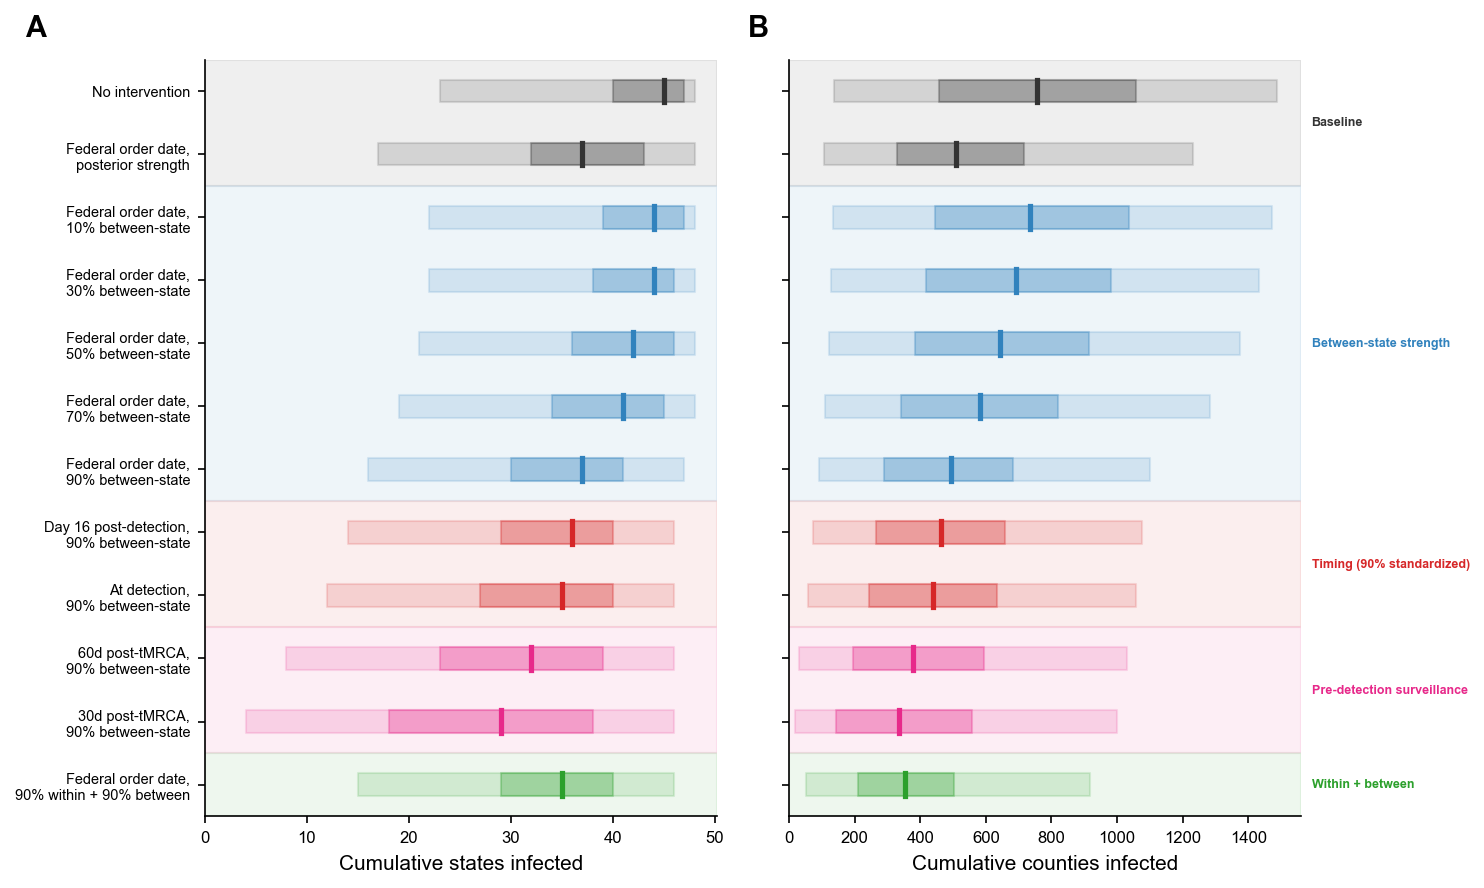

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

n_scenarios = len(S_NPI_SCENARIOS)
labels = [label for _, label, _ in S_NPI_SCENARIOS]
scenarios_fwd = list(S_NPI_SCENARIOS)

# Identify category boundaries for background shading
categories_fwd = [cat for _, _, cat in scenarios_fwd]
cat_blocks = []
i = 0
while i < len(categories_fwd):
    cat = categories_fwd[i]
    j = i
    while j < len(categories_fwd) and categories_fwd[j] == cat:
        j += 1
    cat_blocks.append((cat, i, j - 1))
    i = j

panels = [
    ('n_states', 'Cumulative states infected'),
    ('counties_w104', 'Cumulative counties infected'),
]

bar_height = 0.18

def break_label_snpi(label):
    label = label.replace(' (', '\n(')
    label = label.replace(', ', ',\n')
    return label

for ax_idx, (col, xlabel) in enumerate(panels):
    ax = axes[ax_idx]
    
    # Category background shading — use category colors with low alpha
    for block_idx, (cat, start, end) in enumerate(cat_blocks):
        ax.axhspan(start - 0.5, end + 0.5, color=CATEGORY_COLORS[cat], alpha=0.08, zorder=0)
        # Category label on far right
        mid = (start + end) / 2
        if ax_idx == 1:
            ax.text(1.02, mid, cat, transform=ax.get_yaxis_transform(),
                    fontsize=6, va='center', ha='left', color=CATEGORY_COLORS[cat],
                    fontweight='bold', rotation=0)
    
    for i, (scenario, label, cat) in enumerate(scenarios_fwd):
        color = CATEGORY_COLORS[cat]
        vals = data[scenario][col].values
        med = np.median(vals)
        q025, q25, q75, q975 = np.percentile(vals, [2.5, 25, 75, 97.5])
        y = i
        ax.fill_between([q025, q975], y - bar_height, y + bar_height,
                        color=color, alpha=0.15, zorder=1)
        ax.fill_between([q25, q75], y - bar_height, y + bar_height,
                        color=color, alpha=0.30, zorder=2)
        ax.plot([med, med], [y - bar_height, y + bar_height],
                color=color, lw=2.5, zorder=4)
    
    ax.set_yticks(range(n_scenarios))
    if ax_idx == 0:
        ax.set_yticklabels([break_label_snpi(l) for l in labels], fontsize=7)
        ax.set_xticks([0, 10, 20, 30, 40, 50])
    if ax_idx == 1:
        ax.set_xlim(left=0)
    ax.set_xlabel(xlabel)
    ax.set_ylim(n_scenarios - 0.5, -0.5)
    style_ax(ax)
    panel_label = ['A', 'B'][ax_idx]
    label_x = -0.08 if ax_idx > 0 else -0.35
    ax.text(label_x, 1.06, panel_label,
            transform=ax.transAxes, fontsize=14, fontweight='bold', va='top')

plt.tight_layout()
# fig.savefig(FIG_DIR / 'fig_s_npi_all_scenarios.png')
# fig.savefig(FIG_DIR / 'fig_s_npi_all_scenarios.pdf')
plt.show()
# print(f'Saved to {FIG_DIR / "fig_s_npi_all_scenarios"}.png/.pdf')

## Summary statistics for key comparisons

In [6]:
print('=== Key scenario statistics (counties at 2 years) ===')
print(f'{"Scenario":<45} {"Median":>8} {"50% HPD":>16} {"95% HPD":>16}')
print('-' * 90)
for scenario, label, cat in S_NPI_SCENARIOS:
    vals = data[scenario]['counties_w104'].values
    med = np.median(vals)
    h50 = hpd(vals, 0.50)
    h95 = hpd(vals, 0.95)
    print(f'{label:<45} {med:>8.0f} [{h50[0]:>5.0f}, {h50[1]:>5.0f}] [{h95[0]:>5.0f}, {h95[1]:>5.0f}]')

print()
print('=== Key scenario statistics (states at 2 years) ===')
print(f'{"Scenario":<45} {"Median":>8} {"50% HPD":>16} {"95% HPD":>16}')
print('-' * 90)
for scenario, label, cat in S_NPI_SCENARIOS:
    vals = data[scenario]['n_states'].values
    med = np.median(vals)
    h50 = hpd(vals, 0.50)
    h95 = hpd(vals, 0.95)
    print(f'{label:<45} {med:>8.0f} [{h50[0]:>5.0f}, {h50[1]:>5.0f}] [{h95[0]:>5.0f}, {h95[1]:>5.0f}]')

=== Key scenario statistics (counties at 2 years) ===
Scenario                                        Median          50% HPD          95% HPD
------------------------------------------------------------------------------------------
No intervention                                    755 [  364,   927] [  170,  1511]
Federal order date, posterior strength             510 [  228,   599] [   14,  1129]
Federal order date, 10% between-state              736 [  347,   898] [  162,  1491]
Federal order date, 30% between-state              693 [  326,   850] [  151,  1448]
Federal order date, 50% between-state              644 [  296,   787] [  135,  1384]
Federal order date, 70% between-state              583 [  262,   706] [   14,  1175]
Federal order date, 90% between-state              493 [  199,   567] [   17,  1014]
Day 16 post-detection, 90% between-state           463 [  168,   527] [   11,   979]
At detection, 90% between-state                    438 [  148,   500] [   10,   955]
6